<a href="https://colab.research.google.com/github/Krishna4907/Smart-Energy---NITW/blob/main/Smart_Energty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1 — Upload the zip file
from google.colab import files
uploaded = files.upload()
# A button appears → click it → select DATA.zip from Desktop
# Wait for upload to finish (may take 2-5 minutes depending on size)

# Step 2 — Unzip it
import zipfile
import os

with zipfile.ZipFile('DATA.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/DATA')

print("Extracted! Folder structure:")
for root, dirs, files_list in os.walk('/content/DATA'):
    level = root.replace('/content/DATA', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show first 2 levels
        for f in files_list[:3]:  # show first 3 files only
            print(f'{indent}  {f}')

Saving DATA.zip to DATA.zip
Extracted! Folder structure:
PLAID_DATA/
  DATA/
    fridge/
    Heater/
    microwave/
    fan/
    bulb/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ── FIXED file reader for 2-column PLAID files ─────────────────
def read_plaid_file(filepath):
    """
    Reads PLAID file — handles both 2 and 3 column formats
    """
    if filepath.endswith('.xlsx'):
        df = pd.read_excel(filepath, header=None)
    else:
        df = pd.read_csv(filepath, header=None)

    print(f"Raw shape: {df.shape}")
    print(f"First 3 rows:\n{df.head(3)}\n")

    # Drop any column that is ALL NaN or ALL same value
    df = df.dropna(axis=1, how='all')

    # Now check how many columns remain
    if df.shape[1] == 2:
        df.columns = ['current', 'voltage']
    elif df.shape[1] == 3:
        # First column is just ID number — drop it
        df = df.iloc[:, 1:]
        df.columns = ['current', 'voltage']
    else:
        print(f"Unexpected columns: {df.shape[1]}")
        return None

    # Convert to numbers, drop bad rows
    df['current'] = pd.to_numeric(df['current'], errors='coerce')
    df['voltage'] = pd.to_numeric(df['voltage'], errors='coerce')
    df = df.dropna()

    # Drop the first row if it looks like a header (non-numeric)
    df = df[df['current'].abs() < 100]  # current can't be > 100A

    df = df.reset_index(drop=True)
    return df

# ── Test with your bulb file ────────────────────────────────────
# Change this path to wherever your file is in Colab
df = read_plaid_file('/content/57_processed.xlsx')

if df is not None:
    print(f"✅ Loaded successfully")
    print(f"Rows          : {len(df)}")
    print(f"Current range : {df['current'].min():.3f} to {df['current'].max():.3f} A")
    print(f"Voltage range : {df['voltage'].min():.1f} to {df['voltage'].max():.1f} V")

    # RMS calculations
    current_rms = np.sqrt(np.mean(df['current']**2))
    voltage_rms = np.sqrt(np.mean(df['voltage']**2))
    power = current_rms * voltage_rms

    print(f"\nCurrent RMS   : {current_rms:.3f} A")
    print(f"Voltage RMS   : {voltage_rms:.1f} V")
    print(f"Power         : {power:.1f} W")

Raw shape: (2502, 3)
First 3 rows:
      0     1        2
0  57.0   NaN      NaN
1   NaN -0.12 -0.11127
2   NaN -0.13 -2.36850

✅ Loaded successfully
Rows          : 2501
Current range : -0.790 to 0.810 A
Voltage range : -149.9 to 146.5 V

Current RMS   : 0.563 A
Voltage RMS   : 101.9 V
Power         : 57.3 W


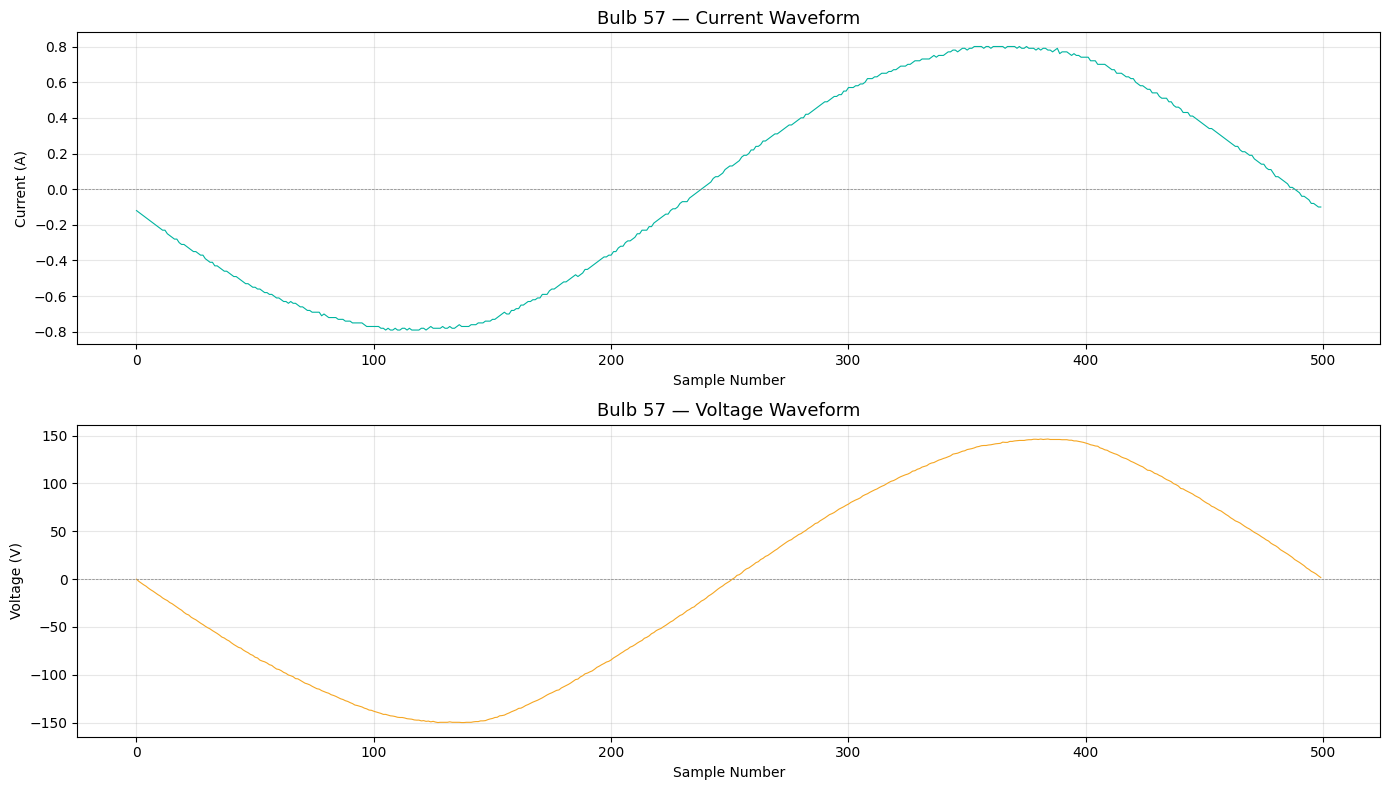

In [ ]:
# ── FIXED plot — uses integer index not column values ──────────
def plot_waveform(df, appliance_name, color='#00B4A0'):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Current wave
    axes[0].plot(df['current'].values[:500],
                 color=color, linewidth=0.8)
    axes[0].axhline(y=0, color='gray',
                    linestyle='--', linewidth=0.5)
    axes[0].set_title(f'{appliance_name} — Current Waveform',
                      fontsize=13)
    axes[0].set_xlabel('Sample Number')
    axes[0].set_ylabel('Current (A)')
    axes[0].grid(True, alpha=0.3)

    # Voltage wave
    axes[1].plot(df['voltage'].values[:500],
                 color='#F5A623', linewidth=0.8)
    axes[1].axhline(y=0, color='gray',
                    linestyle='--', linewidth=0.5)
    axes[1].set_title(f'{appliance_name} — Voltage Waveform',
                      fontsize=13)
    axes[1].set_xlabel('Sample Number')
    axes[1].set_ylabel('Voltage (V)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot your bulb file
plot_waveform(df, 'Bulb 57', color='#00B4A0')

In [ ]:
# ── Load ALL files from ALL appliance folders ───────────────────
def load_all_appliances(base_path, appliance_folders):
    """
    base_path = '/content/DATA/DATA'
    appliance_folders = {'bulb': 'bulb', 'fan': 'fan', 'laptop': 'laptop'}
    """
    all_data = []

    for label, folder_name in appliance_folders.items():
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.exists(folder_path):
            print(f"❌ Not found: {folder_path}")
            continue

        files_list = [f for f in os.listdir(folder_path)
                     if f.endswith('.xlsx') or f.endswith('.csv')]

        print(f"📁 {label}: {len(files_list)} files found")

        for fname in files_list:
            fpath = os.path.join(folder_path, fname)
            df = read_plaid_file(fpath)
            if df is not None and len(df) > 100:
                df['label'] = label
                df['source_file'] = fname
                all_data.append(df)

    if not all_data:
        print("❌ No data loaded — check your paths!")
        return None

    final_df = pd.concat(all_data, ignore_index=True)
    print(f"\n✅ Total rows loaded : {len(final_df)}")
    print(f"Label distribution  :\n{final_df['label'].value_counts()}")
    return final_df

# Run it
base_path = '/content/PLAID_DATA/DATA'  # adjust after unzip

appliances = {
    'bulb'  : 'bulb',
    'fan'   : 'fan',
    'laptop': 'laptop'
}

dataset = load_all_appliances(base_path, appliances)

📁 bulb: 8 files found
Raw shape: (2502, 3)
First 3 rows:
      0     1         2
0  60.0   NaN       NaN
1   NaN -0.12 -0.080193
2   NaN -0.13 -1.890300

Raw shape: (2502, 3)
First 3 rows:
       0     1       2
0  293.0   NaN     NaN
1    NaN -0.06  0.0000
2    NaN -0.06 -1.0544

Raw shape: (2502, 3)
First 3 rows:
       0     1    2
0  121.0   NaN  NaN
1    NaN -0.06  0.0
2    NaN -0.06  0.0

Raw shape: (2502, 3)
First 3 rows:
       0     1    2
0  119.0   NaN  NaN
1    NaN  0.09  0.0
2    NaN  0.09  0.0

Raw shape: (2502, 3)
First 3 rows:
       0     1    2
0  245.0   NaN  NaN
1    NaN -0.09  0.0
2    NaN -0.10  0.0

Raw shape: (2502, 3)
First 3 rows:
      0     1        2
0  57.0   NaN      NaN
1   NaN -0.12 -0.11127
2   NaN -0.13 -2.36850

Raw shape: (2502, 3)
First 3 rows:
       0     1       2
0  147.0   NaN     NaN
1    NaN  0.07  0.0000
2    NaN  0.07 -8.2791

Raw shape: (2502, 3)
First 3 rows:
       0     1    2
0  248.0   NaN  NaN
1    NaN  0.11  0.0
2    NaN  0.12  0.0

Folders found:
['fridge', 'Heater', 'microwave', 'fan', 'bulb']

bulb: 8 files

fan: 8 files

fridge: 21 files
Error reading /content/PLAID_DATA/DATA/fridge/~$105_processed.xlsx
Excel file format cannot be determined, you must specify an engine manually.

heater: 9 files

microwave: 8 files

DATASET SUMMARY
Total rows: 132541

Class Distribution:
label
fridge       50020
heater       22504
bulb         20008
microwave    20008
fan          20001
Name: count, dtype: int64

Testing file:
/content/PLAID_DATA/DATA/bulb/60_processed.xlsx

FILE STATISTICS
Rows          : 2501
Current range : -0.800A to 0.810A
Voltage range : -184.0V to 172.5V
Current RMS   : 0.562 A
Voltage RMS   : 120.1 V
Power         : 67.5 W


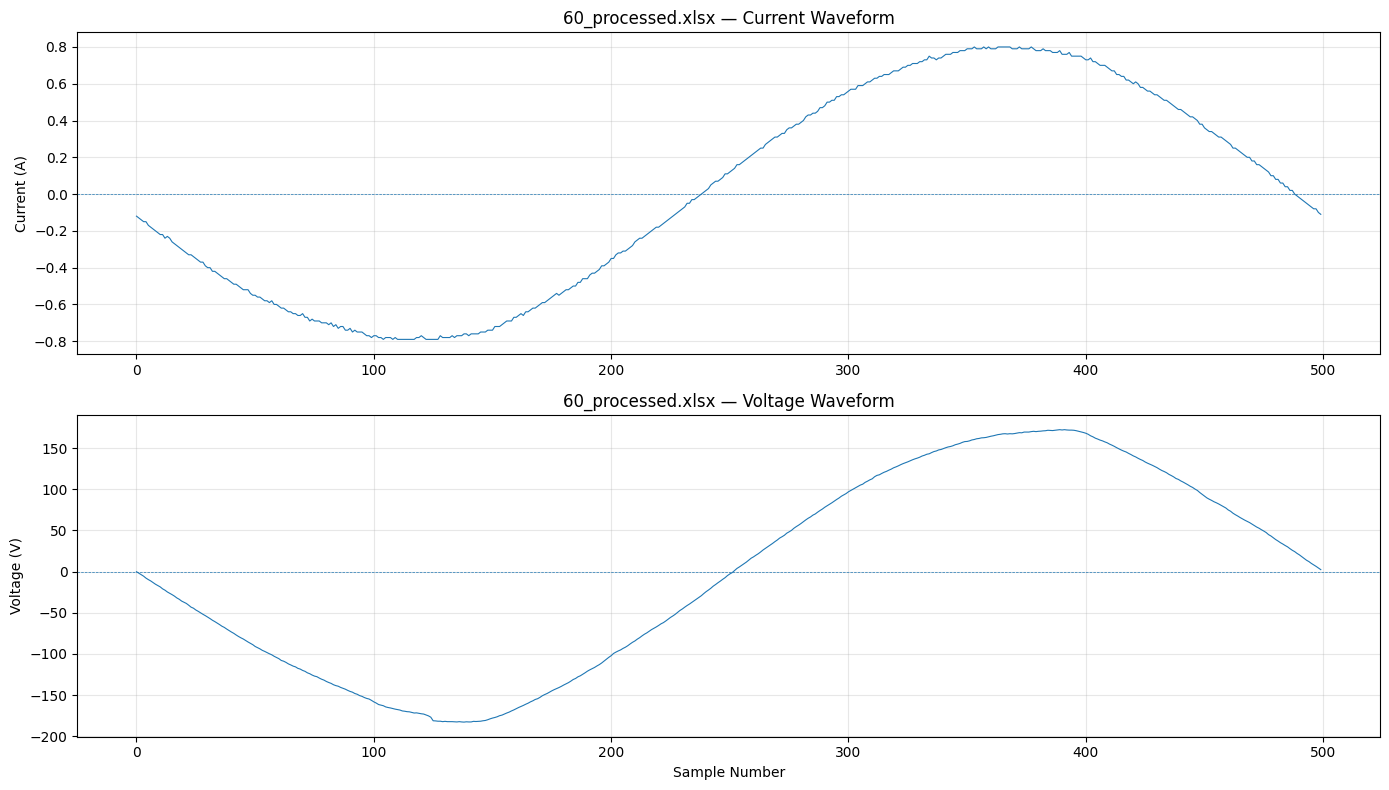


Saved to:
/content/plaid_combined_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# CONFIGURATION
# ============================================================

BASE_PATH = "/content/PLAID_DATA/DATA"

APPLIANCES = {
    "bulb": "bulb",
    "fan": "fan",
    "fridge": "fridge",
    "heater": "Heater",
    "microwave": "microwave"
}

# ============================================================
# READ PLAID FILE
# ============================================================

def read_plaid_file(filepath):

    try:

        if filepath.endswith(".xlsx"):
            df = pd.read_excel(filepath, header=None)
        else:
            df = pd.read_csv(filepath, header=None)

        # remove fully empty rows
        df = df.dropna(how="all")

        # PLAID format:
        # col0 = appliance id
        # col1 = current
        # col2 = voltage

        if df.shape[1] < 3:
            print(f"Skipping {filepath}")
            return None

        df = df.iloc[:, 1:3].copy()

        df.columns = ["current", "voltage"]

        df["current"] = pd.to_numeric(df["current"], errors="coerce")
        df["voltage"] = pd.to_numeric(df["voltage"], errors="coerce")

        df = df.dropna()

        df = df.reset_index(drop=True)

        return df

    except Exception as e:

        print(f"Error reading {filepath}")
        print(e)

        return None


# ============================================================
# FILE STATISTICS
# ============================================================

def show_statistics(df):

    current_rms = np.sqrt(np.mean(df["current"] ** 2))
    voltage_rms = np.sqrt(np.mean(df["voltage"] ** 2))

    power = current_rms * voltage_rms

    print("\n==============================")
    print("FILE STATISTICS")
    print("==============================")

    print(f"Rows          : {len(df)}")

    print(
        f"Current range : "
        f"{df['current'].min():.3f}A "
        f"to "
        f"{df['current'].max():.3f}A"
    )

    print(
        f"Voltage range : "
        f"{df['voltage'].min():.1f}V "
        f"to "
        f"{df['voltage'].max():.1f}V"
    )

    print(f"Current RMS   : {current_rms:.3f} A")
    print(f"Voltage RMS   : {voltage_rms:.1f} V")
    print(f"Power         : {power:.1f} W")


# ============================================================
# PLOT WAVEFORM
# ============================================================

def plot_waveform(df, title):

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(df["current"].values[:500], linewidth=0.8)
    axes[0].axhline(0, linestyle="--", linewidth=0.5)

    axes[0].set_title(f"{title} — Current Waveform")
    axes[0].set_ylabel("Current (A)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df["voltage"].values[:500], linewidth=0.8)
    axes[1].axhline(0, linestyle="--", linewidth=0.5)

    axes[1].set_title(f"{title} — Voltage Waveform")
    axes[1].set_ylabel("Voltage (V)")
    axes[1].set_xlabel("Sample Number")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# LOAD ALL APPLIANCES
# ============================================================

def load_all_appliances(base_path, appliance_folders):

    all_data = []

    for label, folder_name in appliance_folders.items():

        folder_path = os.path.join(base_path, folder_name)

        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue

        files_list = [
            f for f in os.listdir(folder_path)
            if f.endswith(".xlsx") or f.endswith(".csv")
        ]

        print(f"\n{label}: {len(files_list)} files")

        for fname in files_list:

            filepath = os.path.join(folder_path, fname)

            df = read_plaid_file(filepath)

            if df is None:
                continue

            if len(df) < 100:
                continue

            df["label"] = label
            df["source_file"] = fname

            all_data.append(df)

    if len(all_data) == 0:
        print("No files loaded")
        return None

    dataset = pd.concat(all_data, ignore_index=True)

    print("\n==============================")
    print("DATASET SUMMARY")
    print("==============================")

    print("Total rows:", len(dataset))

    print("\nClass Distribution:")
    print(dataset["label"].value_counts())

    return dataset


# ============================================================
# CHECK FOLDER STRUCTURE
# ============================================================

print("Folders found:")
print(os.listdir(BASE_PATH))


# ============================================================
# LOAD ENTIRE DATASET
# ============================================================

dataset = load_all_appliances(
    BASE_PATH,
    APPLIANCES
)


# ============================================================
# TEST ONE BULB FILE
# ============================================================

bulb_folder = os.path.join(BASE_PATH, "bulb")

bulb_files = [
    f for f in os.listdir(bulb_folder)
    if f.endswith(".xlsx") or f.endswith(".csv")
]

if len(bulb_files) > 0:

    test_file = os.path.join(
        bulb_folder,
        bulb_files[0]
    )

    print("\nTesting file:")
    print(test_file)

    bulb_df = read_plaid_file(test_file)

    show_statistics(bulb_df)

    plot_waveform(
        bulb_df,
        bulb_files[0]
    )


# ============================================================
# SAVE COMBINED DATASET
# ============================================================

if dataset is not None:

    output_file = "/content/plaid_combined_dataset.csv"

    dataset.to_csv(
        output_file,
        index=False
    )

    print("\nSaved to:")
    print(output_file)


# ============================================================
# DOWNLOAD CSV TO YOUR COMPUTER
# ============================================================

from google.colab import files

files.download("/content/plaid_combined_dataset.csv")

In [ ]:
import pandas as pd

def read_plaid_file(filepath):

    try:

        if filepath.lower().endswith(".xlsx"):
            df = pd.read_excel(
                filepath,
                header=None,
                engine="openpyxl"
            )

        elif filepath.lower().endswith(".csv"):
            df = pd.read_csv(
                filepath,
                header=None
            )

        else:
            print(f"Skipping unsupported file: {filepath}")
            return None

        df = df.dropna(how="all")

        if df.shape[1] < 3:
            print(f"Unexpected format: {filepath}")
            return None

        df = df.iloc[:, 1:3].copy()

        df.columns = ["current", "voltage"]

        df["current"] = pd.to_numeric(
            df["current"],
            errors="coerce"
        )

        df["voltage"] = pd.to_numeric(
            df["voltage"],
            errors="coerce"
        )

        df = df.dropna().reset_index(drop=True)

        return df

    except Exception as e:

        print(f"\nERROR reading:")
        print(filepath)
        print(e)

        return None

In [ ]:
feature_rows = []

for label, folder_name in APPLIANCES.items():

    folder_path = os.path.join(BASE_PATH, folder_name)

    files_list = [
        f for f in os.listdir(folder_path)
        if f.endswith(".xlsx") or f.endswith(".csv")
    ]

    print(f"{label}: {len(files_list)} files")

    for fname in files_list:

        filepath = os.path.join(folder_path, fname)

        df = read_plaid_file(filepath)

        if df is None:
            continue

        features = extract_features(df)

        features["label"] = label
        features["file"] = fname

        feature_rows.append(features)

feature_dataset = pd.DataFrame(feature_rows)

print(feature_dataset.head())

print("\nShape:")
print(feature_dataset.shape)

bulb: 8 files
fan: 8 files
fridge: 21 files

ERROR reading:
/content/PLAID_DATA/DATA/fridge/~$105_processed.xlsx
File is not a zip file
heater: 9 files
microwave: 8 files
   current_rms  voltage_rms  current_mean  voltage_mean  current_std  \
0     0.561543   120.141060      0.003731     -2.003468     0.561530   
1     0.182184   119.906278      0.002531     -0.372423     0.182167   
2     0.308527   120.010835      0.001855     -4.850000     0.308521   
3     0.306070   119.901364      0.001999     -4.604827     0.306063   
4     0.459054   120.018082      0.002471     -2.700191     0.459047   

   voltage_std  current_peak  voltage_peak  current_crest_factor  \
0   120.124354          0.81        184.04              1.442455   
1   119.905700          0.28        170.81              1.536906   
2   119.912793          0.44        177.27              1.426133   
3   119.812907          0.44        177.70              1.437581   
4   119.987703          0.65        176.37              

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Features
X = feature_dataset.drop(
    columns=["label", "file"]
)

# Target
y = feature_dataset["label"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

# Random Forest
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(acc * 100, 2), "%")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Training samples: 42
Testing samples : 11

Accuracy: 81.82 %

Classification Report
              precision    recall  f1-score   support

        bulb       1.00      1.00      1.00         1
         fan       0.50      0.50      0.50         2
      fridge       0.75      0.75      0.75         4
      heater       1.00      1.00      1.00         2
   microwave       1.00      1.00      1.00         2

    accuracy                           0.82        11
   macro avg       0.85      0.85      0.85        11
weighted avg       0.82      0.82      0.82        11


Confusion Matrix
[[1 0 0 0 0]
 [0 1 1 0 0]
 [0 1 3 0 0]
 [0 0 0 2 0]
 [0 0 0 0 2]]


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

                 feature  importance
8   current_crest_factor    0.169676
10        apparent_power    0.099010
6           current_peak    0.098071
1            voltage_rms    0.097505
5            voltage_std    0.095223
9   voltage_crest_factor    0.090434
2           current_mean    0.079454
4            current_std    0.076520
0            current_rms    0.071048
7           voltage_peak    0.069589
3           voltage_mean    0.053468


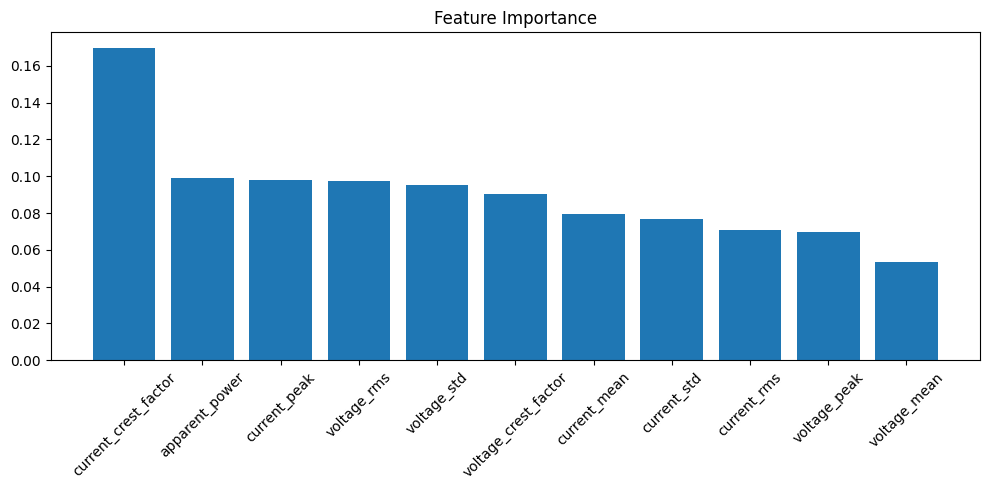

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    importance["feature"],
    importance["importance"]
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.8181818181818182
              precision    recall  f1-score   support

        bulb       1.00      1.00      1.00         1
         fan       0.50      0.50      0.50         2
      fridge       0.75      0.75      0.75         4
      heater       1.00      1.00      1.00         2
   microwave       1.00      1.00      1.00         2

    accuracy                           0.82        11
   macro avg       0.85      0.85      0.85        11
weighted avg       0.82      0.82      0.82        11



In [ ]:
import joblib

joblib.dump(model, "appliance_classifier.pkl")

['appliance_classifier.pkl']

In [ ]:
import pandas as pd
import numpy as np

def extract_features(df):

    current = df["current"].values
    voltage = df["voltage"].values

    current_rms = np.sqrt(np.mean(current**2))
    voltage_rms = np.sqrt(np.mean(voltage**2))

    apparent_power = current_rms * voltage_rms

    features = {

        "current_rms": current_rms,
        "voltage_rms": voltage_rms,

        "current_mean": np.mean(current),
        "voltage_mean": np.mean(voltage),

        "current_std": np.std(current),
        "voltage_std": np.std(voltage),

        "current_peak": np.max(np.abs(current)),
        "voltage_peak": np.max(np.abs(voltage)),

        "current_crest_factor":
            np.max(np.abs(current))/current_rms,

        "voltage_crest_factor":
            np.max(np.abs(voltage))/voltage_rms,

        "apparent_power": apparent_power
    }

    return pd.DataFrame([features])



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 302_processed.xlsx to 302_processed.xlsx


In [ ]:
test_file = "/content/302_processed.xlsx"

df = read_plaid_file(test_file)

print(df.head())   # sanity check

features = extract_features(df)

prediction = model.predict(features)

print("Predicted appliance:", prediction[0])

   current  voltage
0     0.10   0.0000
1     0.08  -1.5946
2     0.07  -3.1892
3     0.06  -4.7838
4     0.05  -7.1757
Predicted appliance: fan


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data1.zip to data1.zip


In [ ]:
import zipfile

with zipfile.ZipFile('data1.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    if 'bulb' in dirs:
        print(root)

/content/data1
/content/DATA


In [ ]:
import os

base_path = "/content/data1"

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):

        files = [
            f for f in os.listdir(folder_path)
            if (f.endswith(".xlsx") or f.endswith(".csv"))
            and not f.startswith("~$")
        ]

        print(f"{folder:15} → {len(files):3} files")

heater          →  84 files
fan             → 209 files
Microwave       → 209 files
Fridge          → 103 files
bulb            → 142 files


In [ ]:
import pandas as pd
import numpy as np
import os

def read_plaid_file(filepath):
    try:
        if filepath.endswith('.xlsx'):
            df = pd.read_excel(filepath, header=None)
        else:
            df = pd.read_csv(filepath, header=None)

        # Handle 2 or 3 column format
        df = df.dropna(axis=1, how='all')
        if df.shape[1] == 3:
            df = df.iloc[:, 1:]
        elif df.shape[1] == 2:
            pass
        else:
            return None

        df.columns = ['current', 'voltage']
        df['current'] = pd.to_numeric(df['current'], errors='coerce')
        df['voltage'] = pd.to_numeric(df['voltage'], errors='coerce')
        df = df.dropna()
        df = df[df['current'].abs() < 100]
        df = df.reset_index(drop=True)

        if len(df) < 100:
            return None
        return df
    except:
        return None

def extract_features(df):
    """
    EXPANDED feature set — fixes fan vs fridge confusion
    """
    current = df['current'].values
    voltage = df['voltage'].values
    power   = current * voltage

    # ── Basic RMS features ─────────────────────────────────
    i_rms   = np.sqrt(np.mean(current**2))
    v_rms   = np.sqrt(np.mean(voltage**2))
    ap      = i_rms * v_rms          # apparent power

    # ── Shape features ─────────────────────────────────────
    i_peak  = np.max(np.abs(current))
    v_peak  = np.max(np.abs(voltage))
    i_std   = np.std(current)
    v_std   = np.std(voltage)

    # ── Crest factors (peak to RMS ratio) ──────────────────
    i_crest = i_peak / (i_rms + 1e-9)
    v_crest = v_peak / (v_rms + 1e-9)

    # ── Power factor ───────────────────────────────────────
    real_power   = np.mean(power)
    power_factor = real_power / (ap + 1e-9)

    # ── NEW: Harmonic features (fixes fan vs fridge) ───────
    # FFT to find frequency components
    fft_vals = np.abs(np.fft.fft(current))
    fft_vals = fft_vals[:len(fft_vals)//2]  # take first half

    # Fundamental and harmonics
    fundamental  = fft_vals[1]   if len(fft_vals) > 1  else 0
    harmonic_2nd = fft_vals[2]   if len(fft_vals) > 2  else 0
    harmonic_3rd = fft_vals[3]   if len(fft_vals) > 3  else 0
    harmonic_5th = fft_vals[5]   if len(fft_vals) > 5  else 0

    # Total Harmonic Distortion ratio
    thd = np.sqrt(harmonic_2nd**2 + harmonic_3rd**2 + harmonic_5th**2)
    thd_ratio = thd / (fundamental + 1e-9)

    # ── NEW: Waveform symmetry ─────────────────────────────
    pos_mean = np.mean(current[current > 0]) if np.any(current > 0) else 0
    neg_mean = np.mean(current[current < 0]) if np.any(current < 0) else 0
    symmetry = abs(pos_mean + neg_mean)  # near 0 = symmetric AC

    # ── NEW: Zero crossing rate ────────────────────────────
    zero_crossings = np.sum(np.diff(np.sign(current)) != 0)
    zcr = zero_crossings / len(current)

    return {
        # Original features
        'i_rms'        : i_rms,
        'v_rms'        : v_rms,
        'apparent_power': ap,
        'i_peak'       : i_peak,
        'v_peak'       : v_peak,
        'i_std'        : i_std,
        'v_std'        : v_std,
        'i_crest'      : i_crest,
        'v_crest'      : v_crest,
        'power_factor' : power_factor,
        'real_power'   : real_power,

        # New harmonic features
        'thd_ratio'    : thd_ratio,
        'harmonic_2nd' : harmonic_2nd,
        'harmonic_3rd' : harmonic_3rd,
        'symmetry'     : symmetry,
        'zcr'          : zcr,
    }

# ── Load ALL files from ALL folders ────────────────────────────
def load_full_dataset(base_path, appliance_list):
    all_features = []
    all_labels   = []
    skipped      = 0

    for appliance in appliance_list:
        folder = os.path.join(base_path, appliance)
        if not os.path.exists(folder):
            print(f"❌ Not found: {folder}")
            continue

        files = [f for f in os.listdir(folder)
                 if f.endswith('.xlsx') or f.endswith('.csv')]
        loaded = 0

        for fname in files:
            fpath = os.path.join(folder, fname)
            df = read_plaid_file(fpath)
            if df is not None:
                feats = extract_features(df)
                all_features.append(feats)
                all_labels.append(appliance)
                loaded += 1
            else:
                skipped += 1

        print(f"✅ {appliance:15} → {loaded} files loaded")

    print(f"\n⚠️  Skipped {skipped} bad files")

    features_df = pd.DataFrame(all_features)
    features_df['label'] = all_labels
    return features_df

# ── Run it ──────────────────────────────────────────────────────
base_path = "/content/data1"

appliances = [
    "bulb",
    "fan",
    "Fridge",
    "heater",
    "Microwave"
]

dataset = load_full_dataset(base_path, appliances)

print(f"\n── Dataset Summary ─────────────────")
print(f"Total samples : {len(dataset)}")
print(f"Features      : {len(dataset.columns) - 1}")
print(dataset['label'].value_counts())

✅ bulb            → 142 files loaded
✅ fan             → 209 files loaded
✅ Fridge          → 103 files loaded
✅ heater          → 84 files loaded
✅ Microwave       → 209 files loaded

⚠️  Skipped 0 bad files

── Dataset Summary ─────────────────
Total samples : 747
Features      : 16
label
fan          209
Microwave    209
bulb         142
Fridge       103
heater        84
Name: count, dtype: int64


Total samples : 747
Features      : 16
Classes       : ['bulb' 'fan' 'Fridge' 'heater' 'Microwave']

── Cross Validation Results ────────
Scores  : ['93.3%', '96.0%', '96.0%', '94.0%', '91.9%']
Mean    : 94.2%
Std dev : 1.6%

── Final Test Accuracy ─────────────
              precision    recall  f1-score   support

      Fridge       0.94      0.71      0.81        21
   Microwave       1.00      0.93      0.96        42
        bulb       0.90      1.00      0.95        28
         fan       0.91      0.98      0.94        42
      heater       0.89      1.00      0.94        17

    accuracy                           0.93       150
   macro avg       0.93      0.92      0.92       150
weighted avg       0.94      0.93      0.93       150



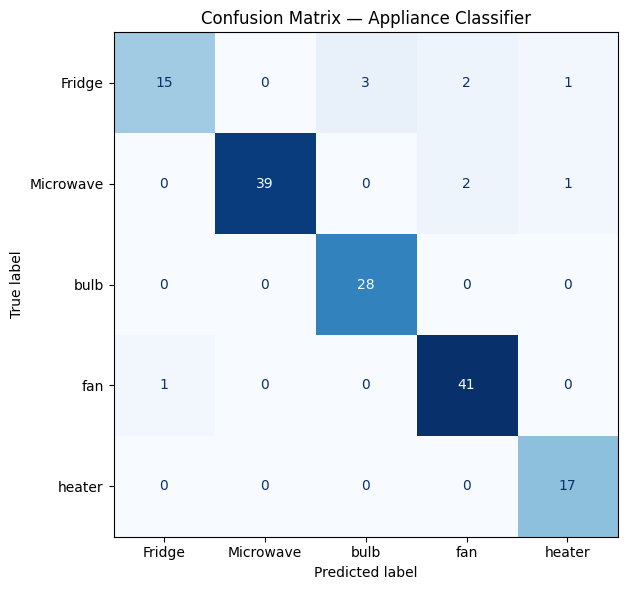

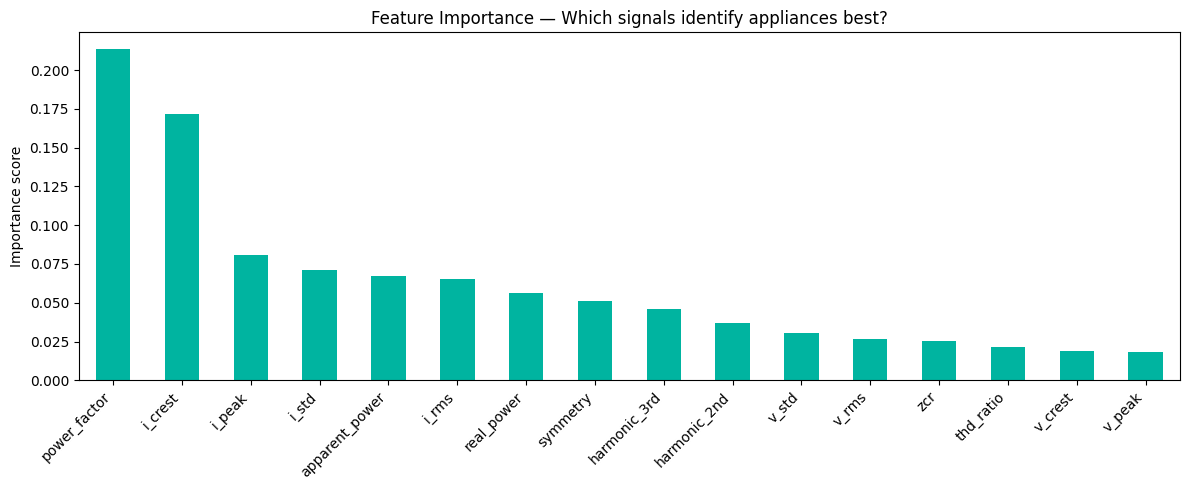


Top 5 features:
power_factor      0.213605
i_crest           0.171680
i_peak            0.080798
i_std             0.070994
apparent_power    0.067451
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split,
                                     cross_val_score,
                                     StratifiedKFold)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── Prepare data ────────────────────────────────────────────────
X = dataset.drop('label', axis=1)
y = dataset['label']

print(f"Total samples : {len(X)}")
print(f"Features      : {X.shape[1]}")
print(f"Classes       : {y.unique()}")

# ── Cross validation (more reliable than single split) ─────────
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    class_weight='balanced',  # handles uneven class sizes
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print(f"\n── Cross Validation Results ────────")
print(f"Scores  : {[f'{s:.1%}' for s in cv_scores]}")
print(f"Mean    : {cv_scores.mean():.1%}")
print(f"Std dev : {cv_scores.std():.1%}")

# ── Final train on full data + test ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"\n── Final Test Accuracy ─────────────")
print(classification_report(y_test, y_pred))

# ── Confusion matrix ────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — Appliance Classifier')
plt.tight_layout()
plt.show()

# ── Feature importance ──────────────────────────────────────────
importances = pd.Series(
    clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind='bar', color='#00B4A0')
plt.title('Feature Importance — Which signals identify appliances best?')
plt.ylabel('Importance score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importances.head(5))

In [ ]:
import pickle

# Save the trained model
with open('appliance_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

# Save feature column names (needed for prediction later)
feature_cols = X.columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("✅ Model saved as appliance_classifier.pkl")
print("✅ Features saved as feature_columns.pkl")
print(f"   {len(feature_cols)} features used")

# Download to your computer
from google.colab import files
files.download('appliance_classifier.pkl')
files.download('feature_columns.pkl')

✅ Model saved as appliance_classifier.pkl
✅ Features saved as feature_columns.pkl
   16 features used


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>